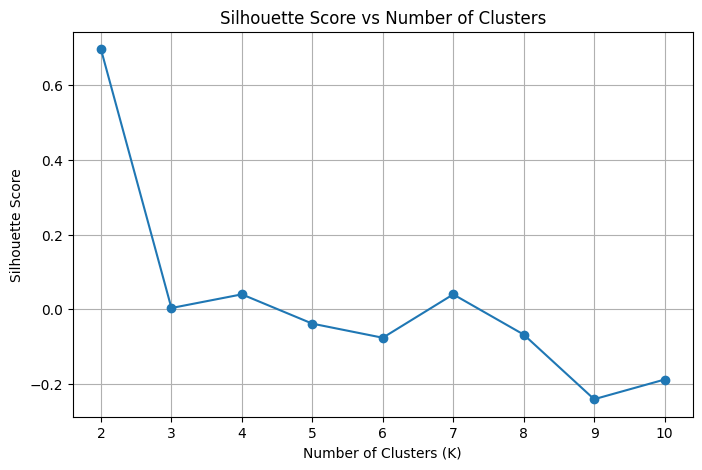

Optimal number of clusters: 2
         release_year  duration_num
Cluster                            
0          2013.88518     72.250596
1          2015.00000    119.000000


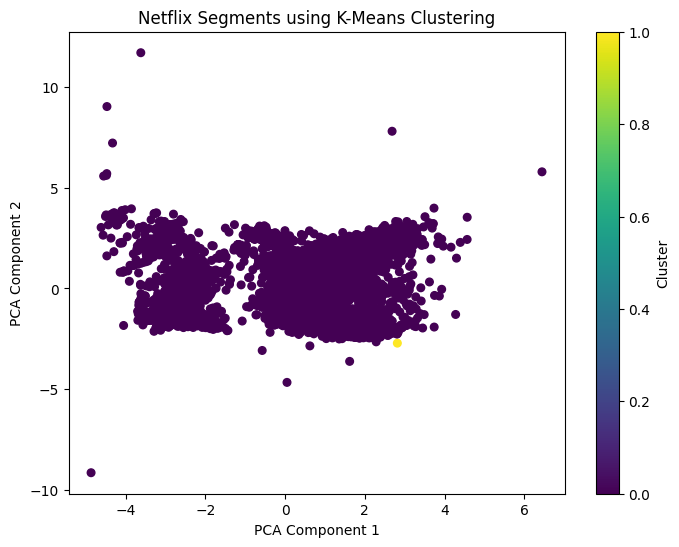

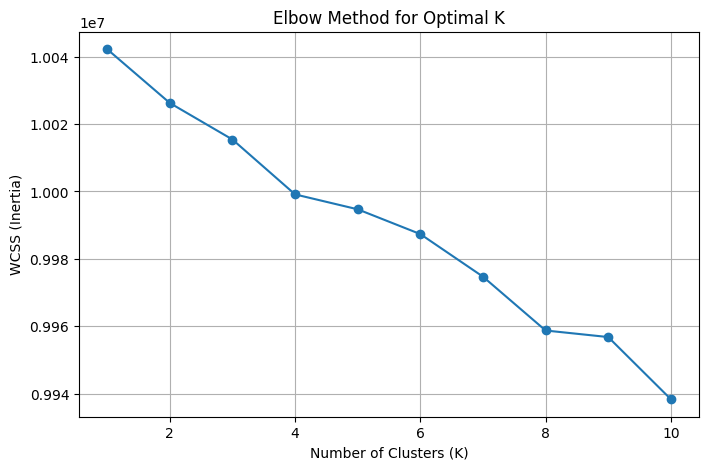

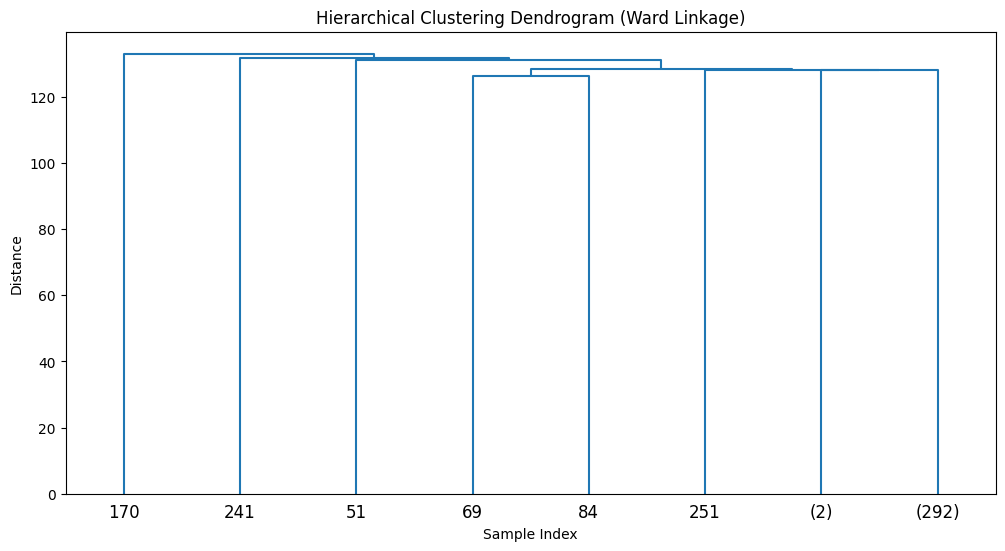

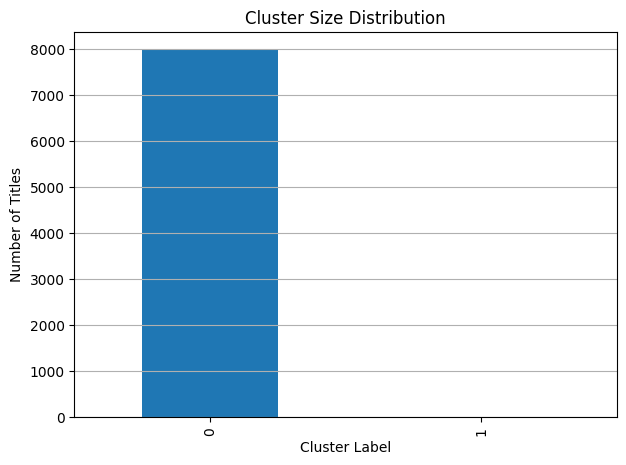

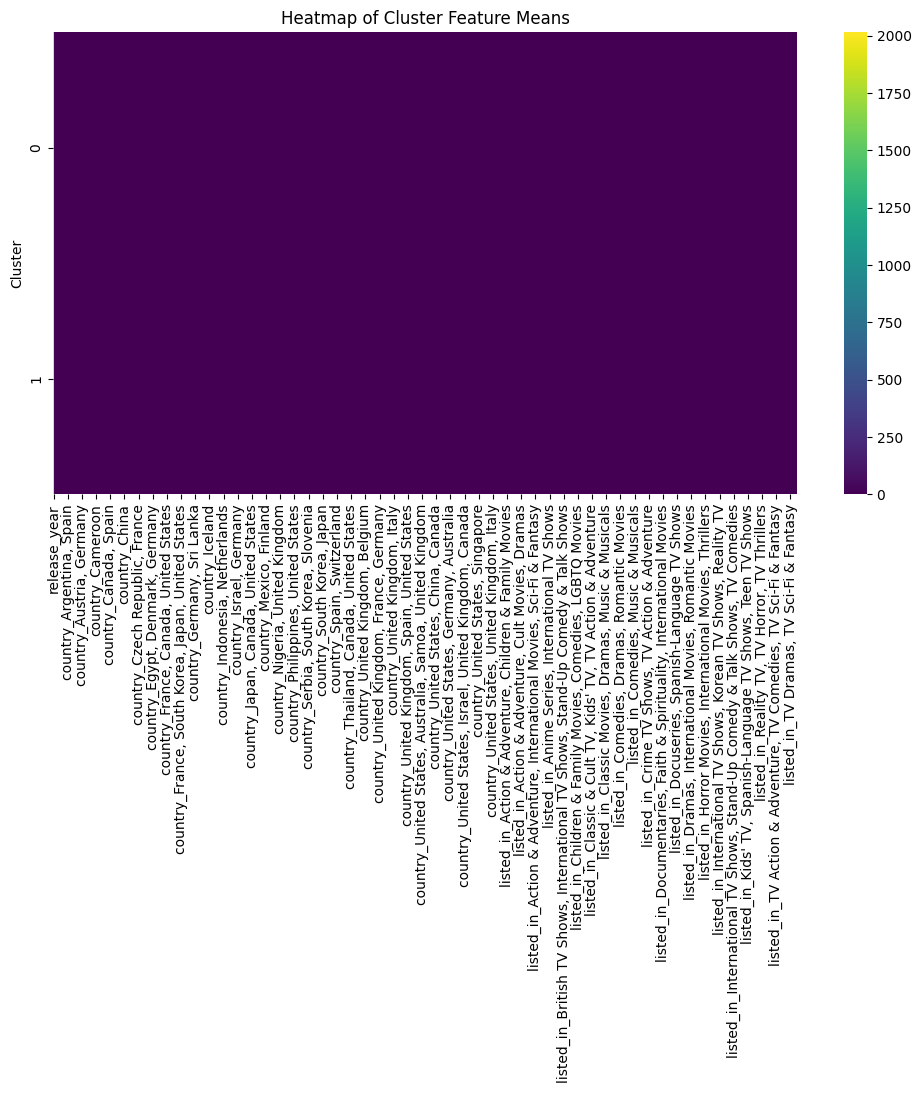

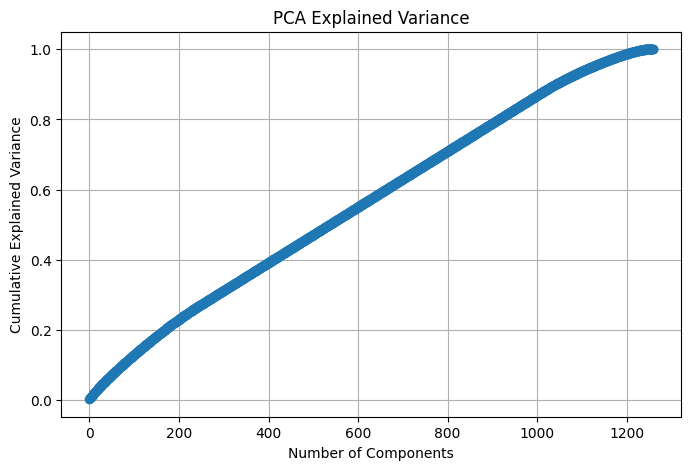

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

# =============================
# LOAD NETFLIX DATASET
# =============================
df = pd.read_csv("netflix_titles.csv")

# =============================
# DATA CLEANING (NETFLIX VERSION)
# =============================
df = df[['type','release_year','rating','country','listed_in','duration']].copy()

# Convert duration text → numeric
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)
df.drop('duration', axis=1, inplace=True)

df.dropna(inplace=True)

# One-hot encode categorical columns
df_encoded = pd.get_dummies(
    df,
    columns=['type','rating','country','listed_in'],
    drop_first=True
)

# =============================
# FEATURES FOR CLUSTERING
# =============================
features = df_encoded.columns.tolist()
X = df_encoded[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =============================
# SILHOUETTE SEARCH
# =============================
silhouette_scores = []
k_values = range(2,11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        max_iter=300,
        random_state=42
    )
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(silhouette_scores)]
print("Optimal number of clusters:", best_k)

# =============================
# FINAL KMEANS MODEL
# =============================
kmeans_final = KMeans(
    n_clusters=best_k,
    init="k-means++",
    n_init=30,
    max_iter=300,
    random_state=42
)

df["Cluster"] = kmeans_final.fit_predict(X_scaled)

cluster_summary = df.groupby("Cluster")[['release_year','duration_num']].mean()
print(cluster_summary)

# =============================
# PCA VISUALIZATION
# =============================
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["Cluster"], cmap="viridis", s=30)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Netflix Segments using K-Means Clustering")
plt.colorbar(label="Cluster")
plt.show()

# =============================
# ELBOW METHOD
# =============================
wcss = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        random_state=42
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal K")
plt.grid(True)
plt.show()

# =============================
# DENDROGRAM (FOR COMPARISON)
# =============================
from scipy.cluster.hierarchy import dendrogram, linkage

sample = X_scaled[:300]
linked = linkage(sample, method="ward")

plt.figure(figsize=(12,6))
dendrogram(linked, truncate_mode="level", p=5)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

# =============================
# CLUSTER SIZE DISTRIBUTION
# =============================
cluster_counts = df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(7,5))
cluster_counts.plot(kind="bar")
plt.xlabel("Cluster Label")
plt.ylabel("Number of Titles")
plt.title("Cluster Size Distribution")
plt.grid(axis="y")
plt.show()

# =============================
# HEATMAP OF CLUSTER MEANS
# =============================
cluster_means = df_encoded.groupby(df["Cluster"]).mean()

plt.figure(figsize=(12,6))
sns.heatmap(cluster_means, cmap="viridis", annot=False)
plt.title("Heatmap of Cluster Feature Means")
plt.show()

# =============================
# PCA EXPLAINED VARIANCE
# =============================
pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()
